In [62]:
from pathlib import Path

path = Path("/Users/carlasequero/Desktop/trabajo-fin-master/solution/data/06_training_data/training_01.h5")

print(path.exists())
print(path.stat().st_size / 1024**2, "MB")

True
255.2816619873047 MB


In [63]:
import h5py

path = "/Users/carlasequero/Desktop/trabajo-fin-master/solution/data/06_training_data/training_01.h5"

with h5py.File(path, "r") as f:
    print(list(f.keys()))

['X', 'X_err', 'gaia_source_id', 'gaia_wavelength_nm', 'sdss_obj_id', 'sdss_wavelength_aa', 'y']


In [64]:
with h5py.File(path, "r") as f:
    print("X:", f["X"].shape)
    print("X_err:", f["X_err"].shape)
    print("y:", f["y"].shape)
    print("gaia wavelengths:", f["gaia_wavelength_nm"].shape)
    print("sdss wavelengths:", f["sdss_wavelength_aa"].shape)

X: (15598, 343)
X_err: (15598, 343)
y: (15598, 3600)
gaia wavelengths: (343,)
sdss wavelengths: (3600,)


In [65]:
import numpy as np

with h5py.File(path, "r") as f:
    X = f["X"][:]
    X_err = f["X_err"][:]
    y = f["y"][:]

    gaia_wavelength = f["gaia_wavelength_nm"][:]
    sdss_wavelength = f["sdss_wavelength_aa"][:]

print(X.shape)
print(y.shape)

(15598, 343)
(15598, 3600)


In [66]:
# Nos quedamos solo con el intervalo común de ambos datos 
gaia_mask = (gaia_wavelength >= 500) & (gaia_wavelength <= 900)
sdss_mask = (sdss_wavelength >= 5000) & (sdss_wavelength <= 9000)

X = X[:, gaia_mask]
X_err = X_err[:, gaia_mask]
y = y[:, sdss_mask]

gaia_wavelength = gaia_wavelength[gaia_mask]
sdss_wavelength = sdss_wavelength[sdss_mask]

print(X.shape)
print(y.shape)

(15598, 201)
(15598, 2666)


In [67]:
import numpy as np

X_model = X
y_model = y

finite_mask = (
    np.isfinite(X_model).all(axis=1)
    & np.isfinite(y_model).all(axis=1)
)

y_p1 = np.nanpercentile(y_model, 1, axis=1)
y_p99 = np.nanpercentile(y_model, 99, axis=1)
y_median_abs = np.nanmedian(np.abs(y_model), axis=1) + 1e-8

dynamic_range = y_p99 - y_p1
relative_range = dynamic_range / y_median_abs

In [68]:
valid = (
    finite_mask
    & (dynamic_range < np.percentile(dynamic_range, 99))
    & (relative_range < np.percentile(relative_range, 99))
)

print("Antes:", X_model.shape[0])
print("Después:", valid.sum())

X_model = X_model[valid]
y_model = y_model[valid]

Antes: 15598
Después: 15286


In [69]:

def group_bines(wavelength, flux, factor = 4):
    n_points_original = flux.shape[1]

    # Definimos la cantidad de puntos a usar como un múltiple del factor (número de bines a agrupar)
    n_points_group = (n_points_original // factor) * factor

    wavelength = wavelength[:n_points_group]
    flux = flux[:, : n_points_group]
    
    grouped_wavelength = wavelength.reshape(-1, factor).mean(axis=1)
    grouped_flux = flux.reshape(flux.shape[0], -1, factor).mean(axis=2)

    return grouped_wavelength, grouped_flux


sdss_wavelength_binned, y_binned = group_bines(
    sdss_wavelength,
    y_model,
    factor=7
)
y_model = y_binned

In [70]:
print(y_model.shape)

(15286, 380)


In [71]:
from sklearn.model_selection import train_test_split

# Separamos en train y temp, luego el temp lo usaremos para separar en test y validation para que los espectros queden mezclados

X_temp, X_test, y_temp, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=23,
    shuffle=True
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.2,
    random_state=23,
    shuffle=True
)

# Normalizamos los datos
X_mean = X_train.mean()
X_std = X_train.std()

y_mean = y_train.mean()
y_std = y_train.std()

X_train_norm = (X_train - X_mean) / X_std
X_val_norm = (X_val - X_mean) / X_std
X_test_norm = (X_test - X_mean) / X_std

y_train_norm = (y_train - y_mean) / y_std
y_val_norm = (y_val - y_mean) / y_std
y_test_norm = (y_test - y_mean) / y_std

In [72]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

n_gaia = X_train.shape[1]
n_sdss = y_train.shape[1]

model = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512),#, activation="elu"),#relu
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm = 1.0),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                │ (None, 512)            │       103,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 380)            │       389,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,117,436 (11.89 MB)

 Trainable params: 3,117,436 (11.89 MB)

 Non-trainable params: 0 (0.00 B)

In [73]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5, # 4 EN SU OPTIMO ESTADO
    restore_best_weights=True
)

from tensorflow.keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train_norm,
    y_train_norm,
    validation_data=(X_val_norm, y_val_norm),
    epochs=50,
    batch_size=64, #32 PARA QUE VAYA EN SU OPTIMO ESTADO
    callbacks=[early_stop,reduce_lr],
    verbose=1
)


Epoch 1/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 0.1080 - mae: 0.2842 - mse: 0.3542 - val_loss: 0.0355 - val_mae: 0.1134 - val_mse: 0.1468 - learning_rate: 1.0000e-04
Epoch 2/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0287 - mae: 0.1054 - mse: 0.1026 - val_loss: 0.0353 - val_mae: 0.1127 - val_mse: 0.1490 - learning_rate: 1.0000e-04
Epoch 3/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0310 - mae: 0.1062 - mse: 0.1162 - val_loss: 0.0300 - val_mae: 0.1015 - val_mse: 0.1228 - learning_rate: 1.0000e-04
Epoch 4/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0234 - mae: 0.0939 - mse: 0.0807 - val_loss: 0.0299 - val_mae: 0.1043 - val_mse: 0.1238 - learning_rate: 1.0000e-04
Epoch 5/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0298 - mae: 0.0992 - mse: 0.1172
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
153/153 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0298 - mae: 0.0991 - mse: 0.1171 - val_loss: 0.0322 - val_ma

In [74]:
y_pred_norm = model.predict(X_test_norm)
y_pred = y_pred_norm * y_std + y_mean

96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


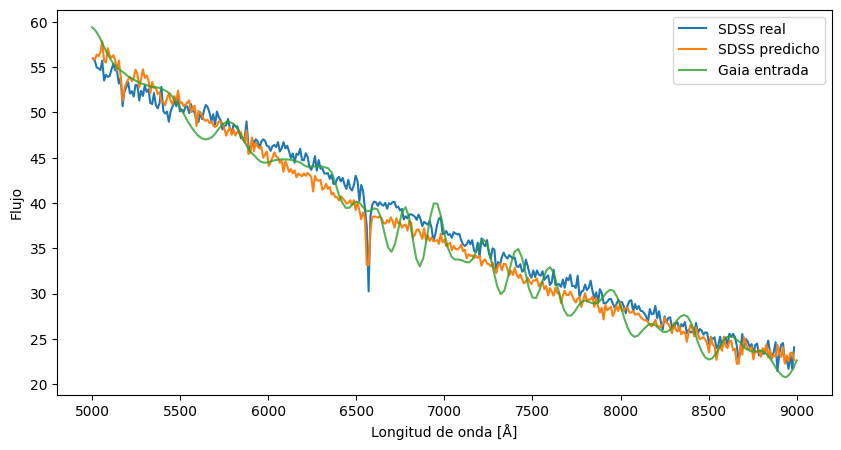

In [75]:
import matplotlib.pyplot as plt

i = 14

gaia_wavelength_ams = gaia_wavelength * 10
gaia_in_sdss_units = X_test[i] / 1e-19

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength_binned, y_test[i], label="SDSS real")
plt.plot(sdss_wavelength_binned, y_pred[i], label="SDSS predicho")
plt.plot(gaia_wavelength_ams, gaia_in_sdss_units, label="Gaia entrada", alpha=0.8)
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()

In [76]:
test_loss, test_mae, test_mse = model.evaluate(
    X_test_norm,
    y_test_norm,
    verbose=1
)

96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0210 - mae: 0.0871 - mse: 0.0673


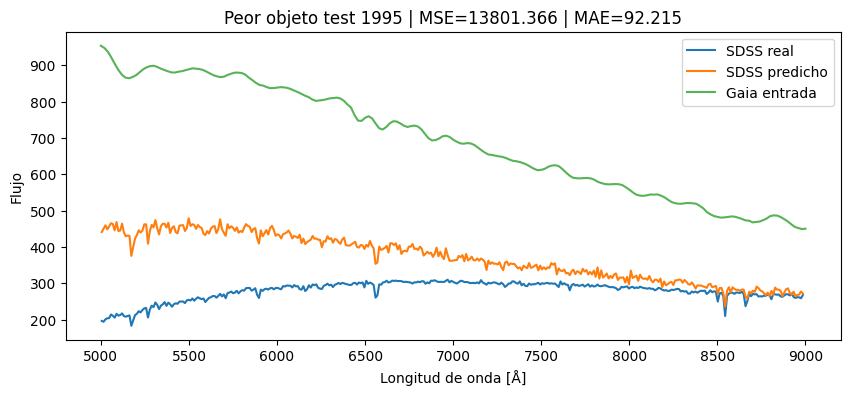

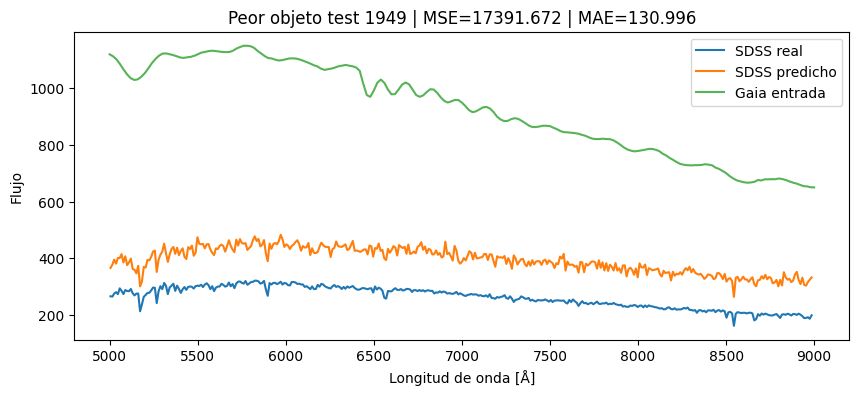

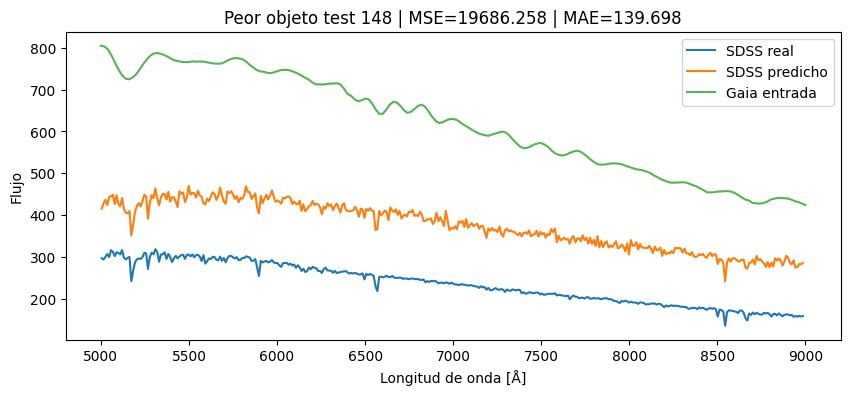

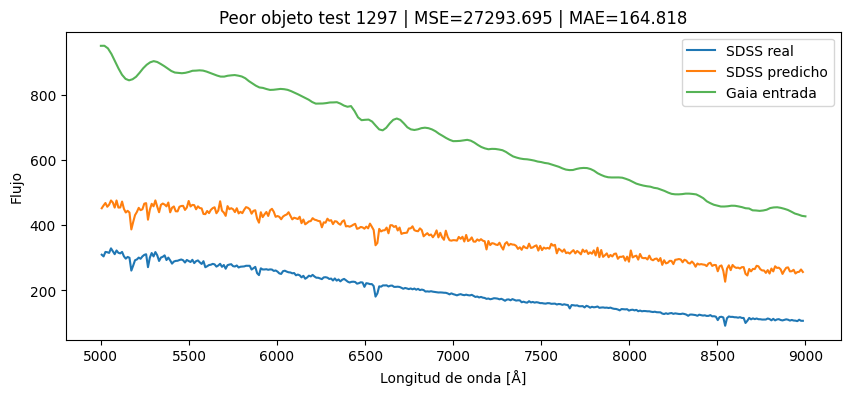

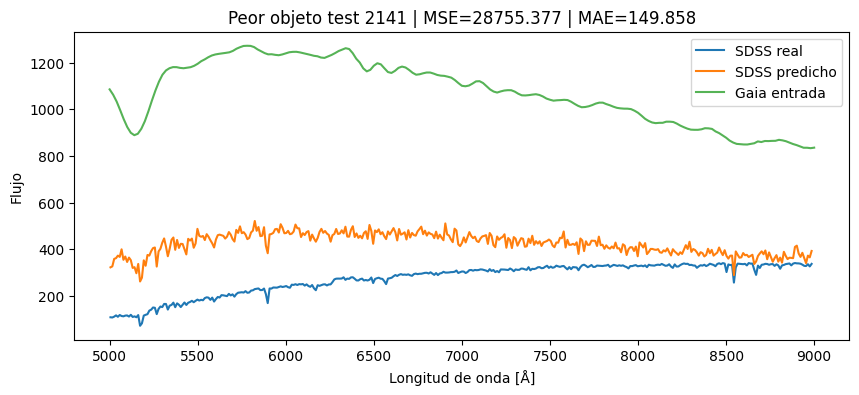

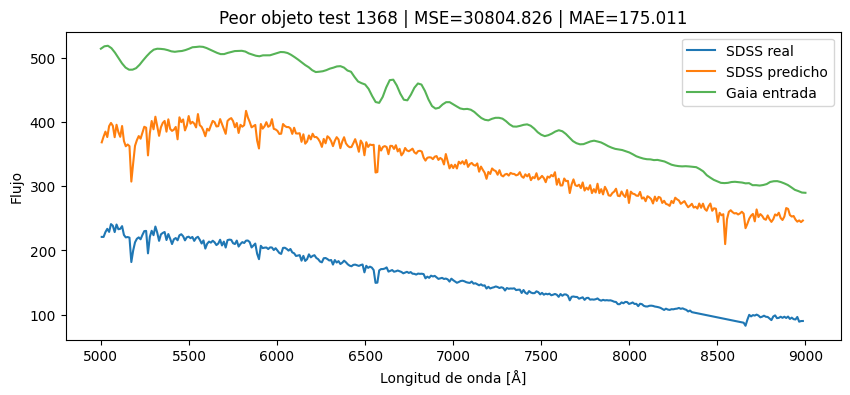

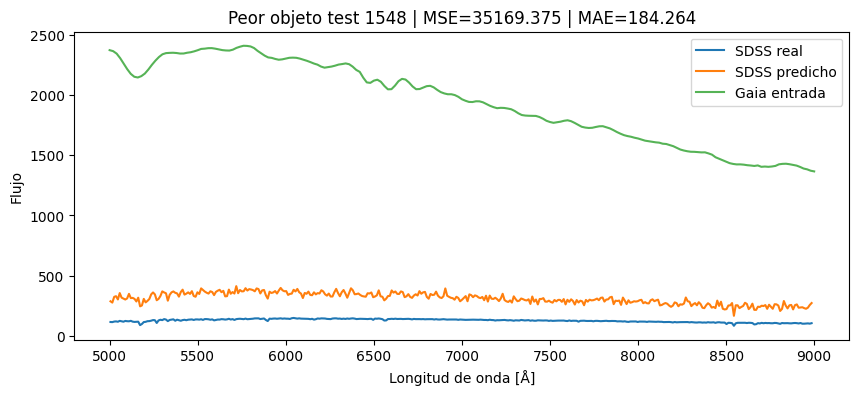

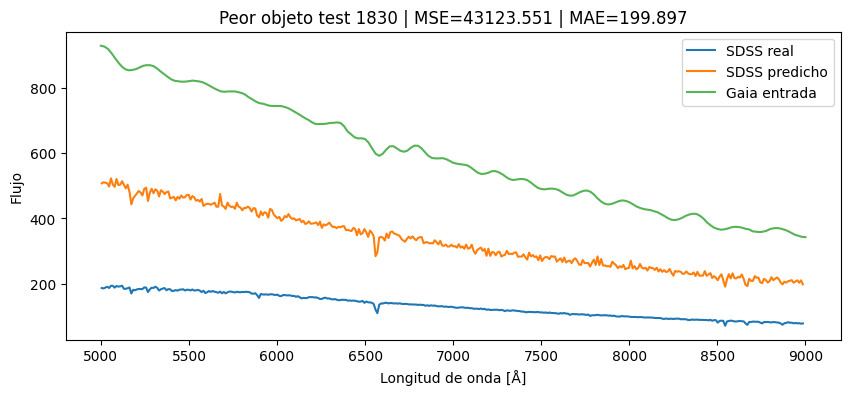

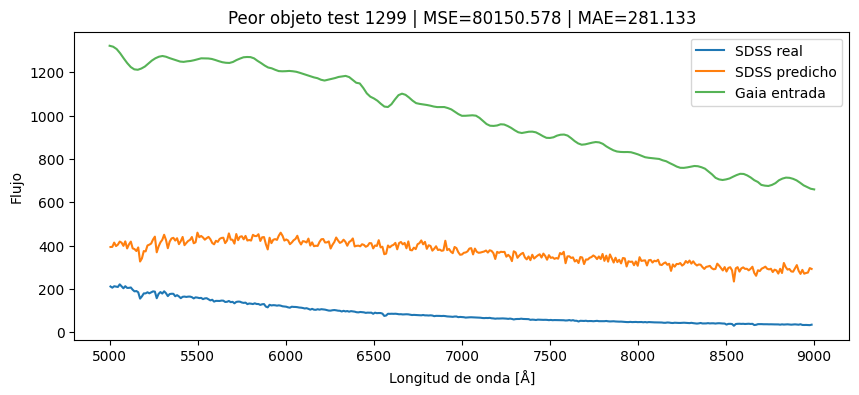

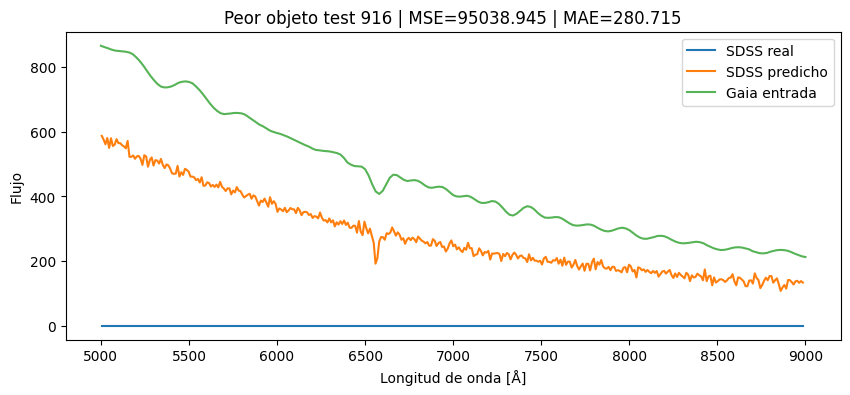

In [77]:
mae = np.mean(np.abs(y_test - y_pred))
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)

mae_per_object = np.mean(np.abs(y_test - y_pred), axis=1)
mse_per_object = np.mean((y_test - y_pred) ** 2, axis=1)
rmse_per_object = np.sqrt(mse_per_object)

worst_idx = np.argsort(mse_per_object)[-10:]

for i in worst_idx:
    gaia_wavelength_ams = gaia_wavelength * 10
    gaia_in_sdss_units = X_test[i] / 1e-19

    plt.figure(figsize=(10, 4))
    plt.plot(sdss_wavelength_binned, y_test[i], label="SDSS real")
    plt.plot(sdss_wavelength_binned, y_pred[i], label="SDSS predicho")
    plt.plot(gaia_wavelength_ams, gaia_in_sdss_units, label="Gaia entrada", alpha=0.8)
    plt.xlabel("Longitud de onda [Å]")
    plt.ylabel("Flujo")
    plt.title(f"Peor objeto test {i} | MSE={mse_per_object[i]:.3f} | MAE={mae_per_object[i]:.3f}")
    plt.legend()
    plt.show()

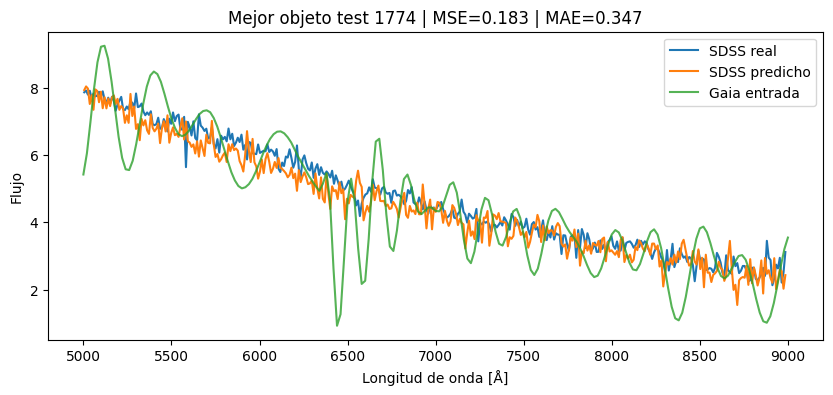

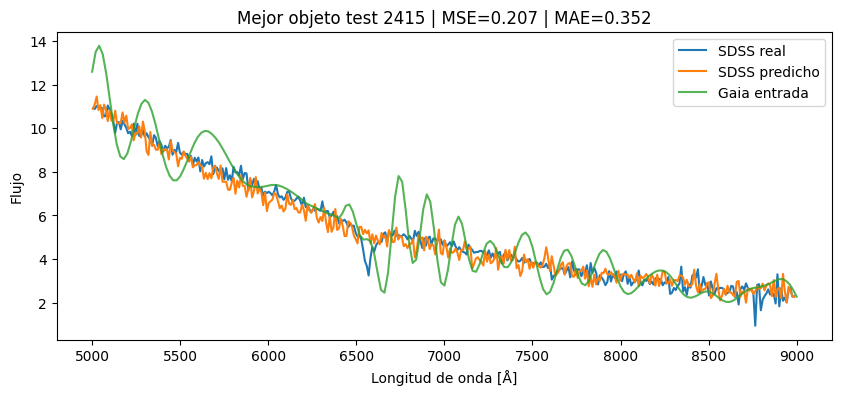

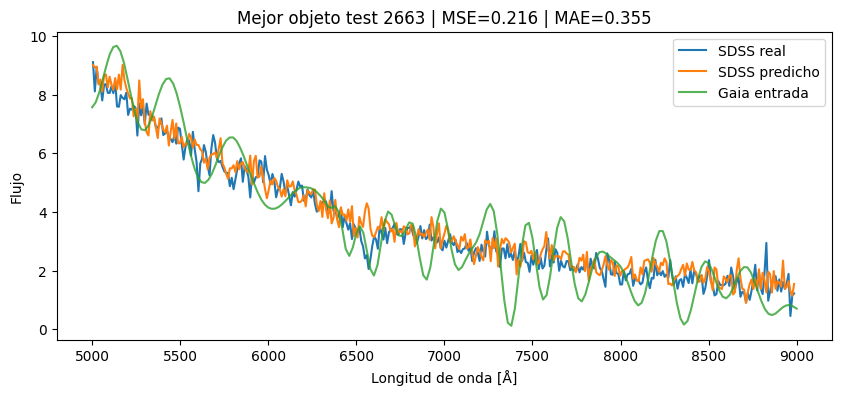

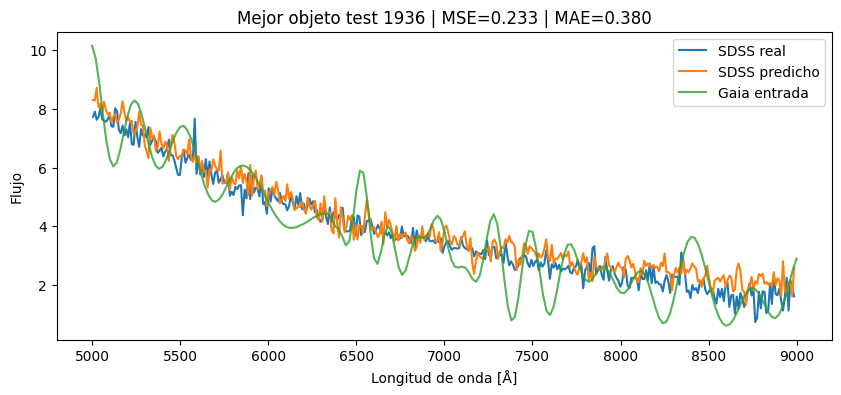

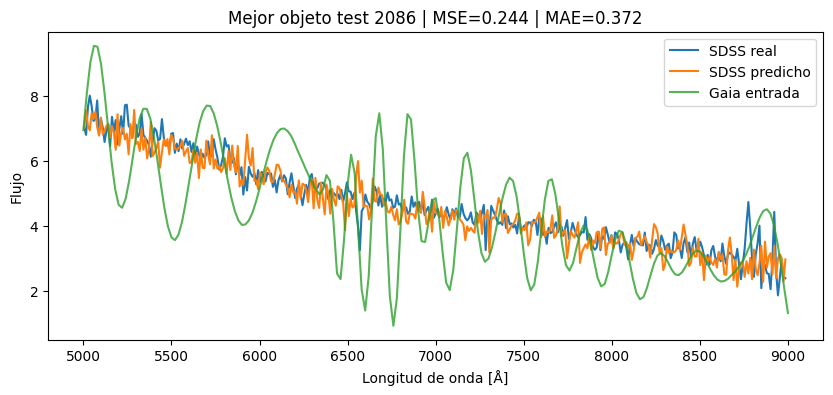

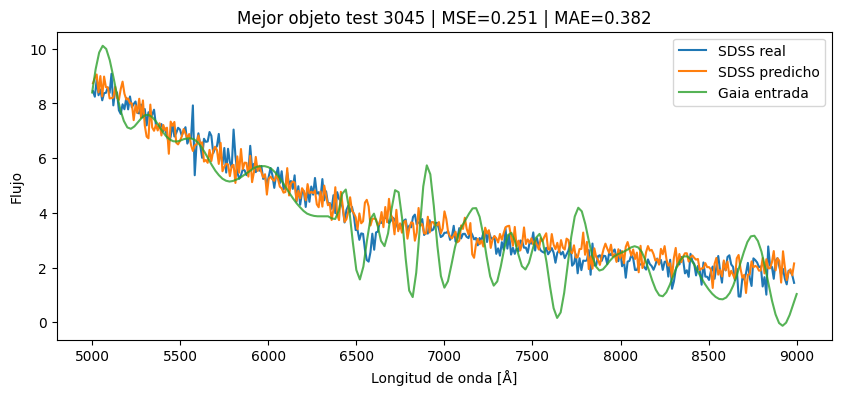

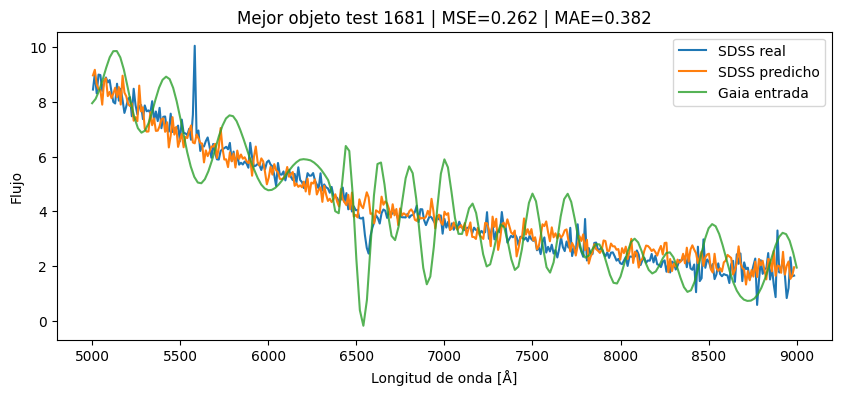

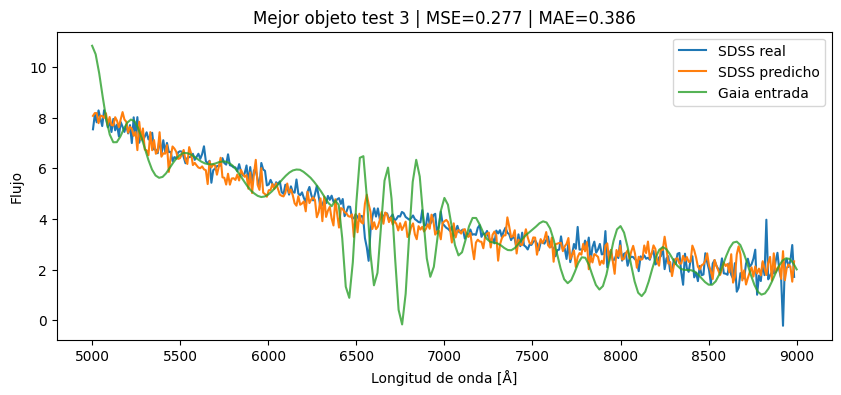

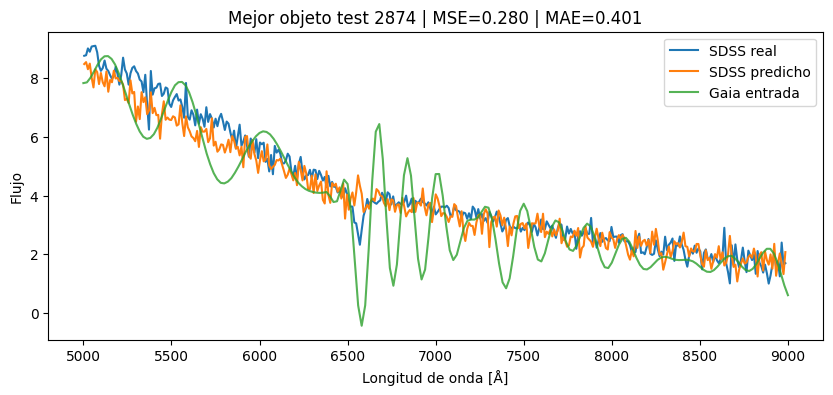

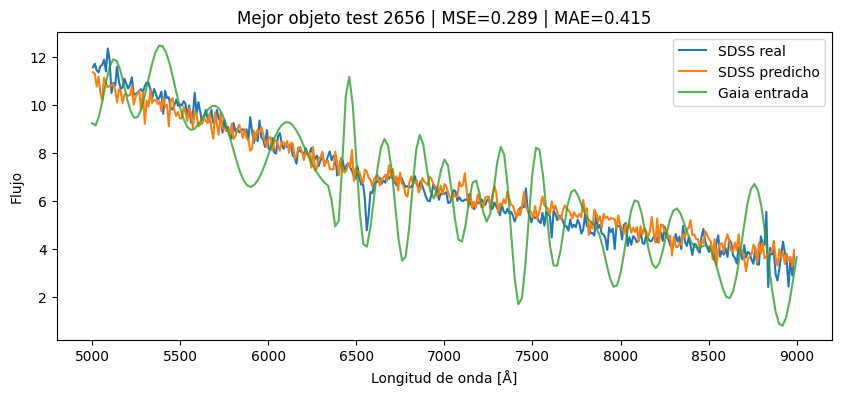

In [78]:
best_idx = np.argsort(mse_per_object)[:10]

for i in best_idx:
    gaia_wavelength_ams = gaia_wavelength * 10
    gaia_in_sdss_units = X_test[i] / 1e-19

    plt.figure(figsize=(10, 4))
    plt.plot(sdss_wavelength_binned, y_test[i], label="SDSS real")
    plt.plot(sdss_wavelength_binned, y_pred[i], label="SDSS predicho")
    plt.plot(gaia_wavelength_ams, gaia_in_sdss_units, label="Gaia entrada", alpha=0.8)
    plt.xlabel("Longitud de onda [Å]")
    plt.ylabel("Flujo")
    plt.title(f"Mejor objeto test {i} | MSE={mse_per_object[i]:.3f} | MAE={mae_per_object[i]:.3f}")
    plt.legend()
    plt.show()

Probamos un modelo diferente par capas convolucionales

In [ ]:
n_gaia = X_train_norm.shape[1]
n_sdss = y_train_norm.shape[1]

# Para Conv1D necesitamos forma (n_objetos, n_puntos, canales)
X_train_cnn = X_train_norm[..., None]
X_val_cnn = X_val_norm[..., None]
X_test_cnn = X_test_norm[..., None]

model_cnn = models.Sequential([
    layers.Input(shape=(n_gaia, 1)),

    layers.Conv1D(32, kernel_size=7, padding="same", activation="elu"),
    layers.Conv1D(64, kernel_size=7, padding="same", activation="elu"),
    layers.Conv1D(128, kernel_size=5, padding="same", activation="elu"),

    layers.Flatten(),

    layers.Dense(512),#, activation="elu"),#relu
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

model_cnn.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_cnn.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 201, 32)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 201, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 201, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25728)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 512)            │    13,173,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_16 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_17 (LeakyReLU)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 380)            │       389,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,243,004 (61.96 MB)

 Trainable params: 16,243,004 (61.96 MB)

 Non-trainable params: 0 (0.00 B)

In [80]:
history = model_cnn.fit(
    X_train_cnn,
    y_train_norm,
    validation_data=(X_val_cnn, y_val_norm),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

Epoch 1/50


306/306 ━━━━━━━━━━━━━━━━━━━━ 42s 130ms/step - loss: 0.1011 - mae: 0.2689 - mse: 0.3410 - val_loss: 0.0325 - val_mae: 0.1076 - val_mse: 0.1305 - learning_rate: 1.0000e-04
Epoch 2/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 41s 135ms/step - loss: 0.0304 - mae: 0.1092 - mse: 0.1111 - val_loss: 0.0407 - val_mae: 0.1500 - val_mse: 0.1478 - learning_rate: 1.0000e-04
Epoch 3/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 36s 116ms/step - loss: 0.0253 - mae: 0.1028 - mse: 0.0877 - val_loss: 0.0323 - val_mae: 0.1039 - val_mse: 0.1368 - learning_rate: 1.0000e-04
Epoch 4/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 38s 124ms/step - loss: 0.0277 - mae: 0.1005 - mse: 0.1062 - val_loss: 0.0298 - val_mae: 0.1041 - val_mse: 0.1175 - learning_rate: 1.0000e-04
Epoch 5/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 36s 117ms/step - loss: 0.0293 - mae: 0.1027 - mse: 0.1102 - val_loss: 0.0283 - val_mae: 0.1007 - val_mse: 0.1152 - learning_rate: 1.0000e-04
Epoch 6/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 38s 124ms/step - loss: 0.0254 - mae: 0.0990 - mse: 0.0859 - val_lo

In [81]:
test_loss, test_mae, test_mse = model_cnn.evaluate(
    X_test_cnn,
    y_test_norm,
    verbose=1
)

96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0200 - mae: 0.0879 - mse: 0.0624


In [82]:
y_pred_norm_cnn = model_cnn.predict(X_test_cnn)
y_pred_cnn = y_pred_norm * y_std + y_mean
y_test_recalculated_cnn = y_test_norm * y_std + y_mean

96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


ValueError: x and y must have same first dimension, but have shapes (2666,) and (380,)

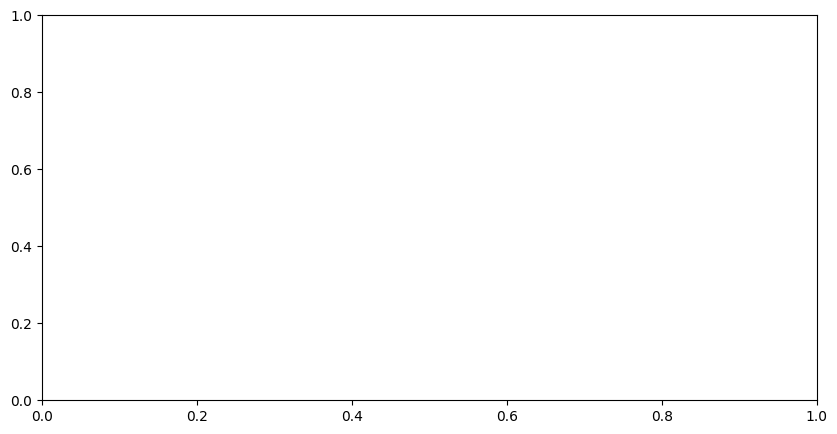

In [ ]:
import matplotlib.pyplot as plt

i = 14

gaia_wavelength_ams = gaia_wavelength * 10
gaia_in_sdss_units_cnn = X_test[i] / 1e-19

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength_binned, y_test[i], label="SDSS real")
plt.plot(sdss_wavelength, y_pred_cnn[i], label="SDSS predicho")
plt.plot(gaia_wavelength_ams, gaia_in_sdss_units, label="Gaia entrada", alpha=0.8)
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()